# Day 3—Turning text into data
*Measuring Manuscripts*

Before a computer can count words, you have to define a word, and the definition shapes everything downstream. Today we cut running text into units—tokens, types, lemmas—and build the two oldest tools in the field: a frequency list and a concordance.

## 1. Load a text

A short public-domain fable is built in so everything runs. Replace it with your own corpus once the pieces are clear.

In [39]:
import urllib.request

CORPUS_URL = "https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/refs/heads/main/Workbook/Day%200%20Teaser%E2%80%94What%20is%20Computational%20Philology/Canterbury%20Tales.txt"
text = urllib.request.urlopen(CORPUS_URL).read().decode("utf-8")

print(text[:120], '...')

WHEN that Aprilis with his showers swoot 
The drought of March hath pierced to the root 
And bathed every vein in such ...


## 2. Tokenizing: splitting text into words

Splitting on spaces is the obvious move, but punctuation and capitals need handling. Is *cloak.* the same token as *cloak*? Is *Sun* the same as *sun*? Watch the count change as we normalize.

In [40]:
naive = text.split()
clean = [w.lower().strip('.,;:!?') for w in text.split()]

print('Naive split:        ', len(naive), 'tokens,', len(set(naive)), 'types')
print('Lowercased, stripped:', len(clean), 'tokens,', len(set(clean)), 'types')
print('\nWe lost', len(set(naive)) - len(set(clean)), 'apparent types just by cleaning up.')

Naive split:         6672 tokens, 1931 types
Lowercased, stripped: 6672 tokens, 1790 types

We lost 141 apparent types just by cleaning up.


## 3. Types, tokens, and the rare words

A **token** is each running word; a **type** is each distinct form. Words that occur exactly once are *hapax legomena*, and there are always more of them than you'd guess.

In [41]:
from collections import Counter
tokens = clean
freq = Counter(tokens)
hapax = [w for w, n in freq.items() if n == 1]

print('Tokens:', len(tokens))
print('Types: ', len(freq))
print('Hapax legomena (appear once):', len(hapax), '->', hapax[:8], '...')

Tokens: 6672
Types:  1790
Hapax legomena (appear once): 1207 -> ['aprilis', 'showers', 'swoot', 'march', 'pierced', 'bathed', 'vein', 'licour'] ...


### Type-token ratio falls as a text grows

The **type-token ratio** (TTR) is types divided by tokens—a rough measure of how varied the vocabulary looks. But it *drops* as a text gets longer, because a long text keeps reusing words it already has. So you can't compare raw TTR across texts of different lengths. We show the fall by measuring TTR on growing slices of the same text.

> The fable is short, so the curve is bumpy. On a long text the downward slide is smooth and unmistakable.

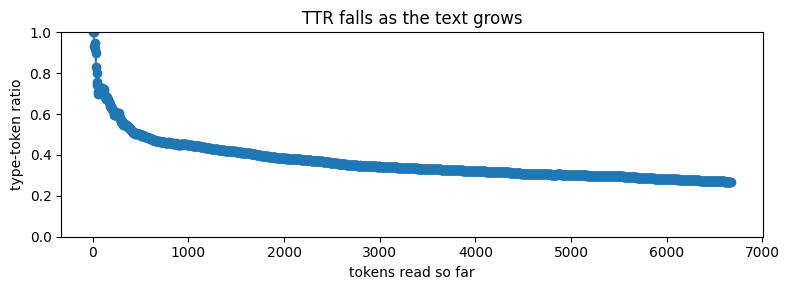

TTR over first 20 tokens:  0.95
TTR over the whole text:   0.27


In [42]:
import numpy as np
import matplotlib.pyplot as plt

sizes = list(range(5, len(tokens) + 1, 5))
ttrs = [len(set(tokens[:n])) / n for n in sizes]

plt.figure(figsize=(8, 3))
plt.plot(sizes, ttrs, marker='o')
plt.xlabel('tokens read so far'); plt.ylabel('type-token ratio')
plt.title('TTR falls as the text grows'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

print(f'TTR over first 20 tokens:  {len(set(tokens[:20]))/20:.2f}')
print(f'TTR over the whole text:   {len(set(tokens))/len(tokens):.2f}')

## 4. Frequency list, with a picture

and        353
he         278
a          257
his        215
was        206
of         204
the        153
in         143
that       125
to         117
as         102
for        90


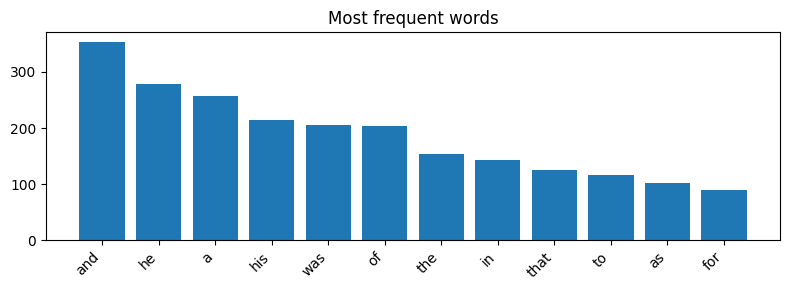

In [43]:
import matplotlib.pyplot as plt
top = freq.most_common(12)
for word, n in top:
    print(f'{word:10} {n}')

labels = [w for w, _ in top]
counts = [n for _, n in top]
plt.figure(figsize=(8, 3))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha='right'); plt.title('Most frequent words'); plt.tight_layout(); plt.show()

The most frequent words are almost always grammatical—*the*, *and*, *of*. The informative words begin further down the list. Day 6 measures how this distribution behaves.

### Stopwords: clearing the dull top of the list

The top of a frequency list is almost always function words—*the*, *and*, *of*. A **stopword** list is a set of common function words we drop before counting, so the content words rise to the top. Compare the list before and after.

In [44]:
# A small, generic English stopword list
STOPWORDS = {
    'the','a','an','and','or','but','of','to','in','on','at','by','for','with',
    'as','is','was','were','be','been','that','this','which','who','his','her',
    'he','she','it','they','them','him','so','then','than','did','do','could',
    'up','off','out','when','their','more','one','other','two','around',
}

content = [w for w in tokens if w and w not in STOPWORDS]
freq_content = Counter(content)

print('Top 8 WITH stopwords:')
for w, n in freq.most_common(8):
    print(f'  {w:10} {n}')
print('\nTop 8 WITHOUT stopwords:')
for w, n in freq_content.most_common(8):
    print(f'  {w:10} {n}')

Top 8 WITH stopwords:
  and        353
  he         278
  a          257
  his        215
  was        206
  of         204
  the        153
  in         143

Top 8 WITHOUT stopwords:
  had        64
  well       59
  full       58
  all        48
  i          48
  there      45
  not        35
  no         32


## 5. Keyword in context (KWIC)

A concordance shows every occurrence of a word with its neighbors. Regularities invisible in running text become obvious once the occurrences are aligned.

In this case, we're going to hypothesize the meaning of an unfamiliar word: wight.

In [45]:
def kwic(tokens, keyword, width=4):
    hits = 0
    for k, w in enumerate(tokens):
        if w == keyword:
            left  = ' '.join(tokens[max(0, k - width):k])
            right = ' '.join(tokens[k + 1:k + 1 + width])
            print(f'{left:>28}  [ {keyword} ]  {right}')
            hits += 1
    if not hits:
        print(f'{keyword!r} not found. Try one of:', [w for w, _ in freq.most_common(10)])

kwic(tokens, 'wight')

         life unto no manner  [ wight ]  he was a very
        beset there wiste no  [ wight ]  that he was in
       thing there coulde no  [ wight ]  pinch at his writing
        sake for every poore  [ wight ]  withouten hire if it
        anon to drawen every  [ wight ]  began and shortly for
          and glad was every  [ wight ]  and tell he must


## 6. Collocations: what sits next to a word

Which words tend to appear beside a given word? That's a first, rough measure of meaning by association.

In [46]:
def neighbours(tokens, keyword, width=2):
    near = Counter()
    for k, w in enumerate(tokens):
        if w == keyword:
            for j in range(max(0, k - width), min(len(tokens), k + width + 1)):
                if j != k:
                    near[tokens[j]] += 1
    return near.most_common(8)

print('Words near "wind":', neighbours(tokens, 'wind'))

Words near "wind": [('a', 1), ('whistling', 1), ('as', 1), ('clear', 1)]


## 6b. N-grams: bigrams and trigrams

An **n-gram** is a run of *n* consecutive tokens. Counting frequent bigrams (pairs) and trigrams (triples) gives a first window on a text's phraseology—its set phrases and formulae. On formulaic material (liturgy, legal forms, colophons) the frequent n-grams pull the formulae straight out of the text.

In [ ]:
def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

bigrams  = Counter(ngrams(tokens, 2))
trigrams = Counter(ngrams(tokens, 3))

print('Most common bigrams:')
for gram, n in bigrams.most_common(6):
    print(f'  {" ".join(gram):24} {n}')
print('\nMost common trigrams:')
for gram, n in trigrams.most_common(6):
    print(f'  {" ".join(gram):28} {n}')

Most common bigrams:
  he was                   56
  of his                   28
  for to                   26
  there was                22
  in his                   22
  had he                   22

Most common trigrams:
  he was a                     13
  well could he                11
  he had a                     7
  as is a                      6
  there was no                 5
  there was a                  5


### A richer collocation view

Below: for any keyword, the words that most often sit within two positions of it, ignoring stopwords so the informative neighbours show through.

In [48]:
def collocates(tokens, keyword, width=2, drop_stop=True):
    near = Counter()
    for k, w in enumerate(tokens):
        if w == keyword:
            for j in range(max(0, k - width), min(len(tokens), k + width + 1)):
                if j != k:
                    neighbour = tokens[j]
                    if drop_stop and neighbour in STOPWORDS:
                        continue
                    near[neighbour] += 1
    return near.most_common(8)

for kw in ('wind', 'sun', 'cloak'):
    print(f'{kw:8} ->', collocates(tokens, kw))

wind     -> [('whistling', 1), ('clear', 1)]
sun      -> [('younge', 1), ('hath', 1)]
cloak    -> [('i', 1)]


## 7. Lemmatizing (the idea)

*blew*, *blow*, and *blowing* are three tokens but one **lemma**. A real lemmatizer knows the whole language; the version here is a small hand-built map, enough to show the move. A real corpus needs a proper tool.

In [49]:
lemma_map = {
    'blew': 'blow', 'blows': 'blow', 'blowing': 'blow',
    'was': 'be', 'were': 'be', 'is': 'be',
}
lemmatized = [lemma_map.get(w, w) for w in tokens]

print('blow (all forms):', Counter(lemmatized)['blow'], 'occurrences after lemmatizing')
# === TO BUILD: replace lemma_map with a real lemmatizer for your language ===

blow (all forms): 1 occurrences after lemmatizing


## 7b. Searching with regular expressions

Often you don't need to lemmatize the whole text—you just want to *find* something. A **regular expression** (regex) is a compact pattern language. `.` matches any character, `*` means zero-or-more, `[aeiou]` matches one vowel, `u?` makes a *u* optional, `a|b` matches either. With regex you can pull every form of a word across a corpus at once.

In [50]:
import re

# Find every word built on the stem 'blow' / 'blew' (b + l + something + w)
pattern = re.compile(r'\bbl\w*w\b')
print('matches for bl...w:', pattern.findall(text.lower()))

# Find both spellings at once with an optional letter: travel(l)er
print('travel(l)er:', re.findall(r'travell?er', text.lower()))

# Find any of several words with alternation
print('wind|sun|cloak:', re.findall(r'\b(?:wind|sun|cloak)\b', text.lower()))

# === TO BUILD: write a regex for a name or verb-ending in your own language ===

matches for bl...w: ['blow']
travel(l)er: []
wind|sun|cloak: ['sun', 'cloak', 'wind']


## 8. Compare two texts

Most philological questions are comparative. The simplest comparison: which words appear in one text but not the other?

In [51]:
text_b = 'the sun was warm and the traveler was glad to rest in the warm sun'.split()
set_a, set_b = set(tokens), set(text_b)

print('Only in the fable:', sorted(set_a - set_b)[:10], '...')
print('Only in text B:   ', sorted(set_b - set_a))
print('Shared:           ', sorted(set_a & set_b))

Only in the fable: ['a', 'a-morrow', 'abbot', 'able', 'about', 'above', 'absolution', 'accord', 'accordant', 'accorded'] ...
Only in text B:    ['traveler', 'warm']
Shared:            ['and', 'glad', 'in', 'rest', 'sun', 'the', 'to', 'was']


## 9. Link a word to a glossary

> 🔧 **TO BUILD**—connect a few words to real glossary entries. The link is just a mapping from a word to a URL.

In [52]:
# === TO BUILD: map a few words to real glossary entries ===
glossary = {
    # 'word': 'https://zodiacglossary.github.io/entry/...',
}
for w in list(freq)[:5]:
    print(f'{w:10} ->', glossary.get(w, '(no entry yet)'))

when       -> (no entry yet)
that       -> (no entry yet)
aprilis    -> (no entry yet)
with       -> (no entry yet)
his        -> (no entry yet)


## Your turn & project check-in
- Run the concordance on a different word. Anything unexpected in how it's used?
- **Check-in:** what's your corpus, and what counts as one unit in it—token, lemma, or sign?